# GLIMMER on AZT1D and OhioT1DM: findings

*A presentation-style walkthrough of this project's findings. Every chart and table here is built from already-computed results (trained models' saved predictions, the genetic algorithm's saved search results) -- nothing is retrained or re-run to produce this notebook. For the full detailed record, including all code, see notebooks 01-06.*

## Table of contents

1. [The goal](#1-the-goal)
2. [The data](#2-the-data)
3. [What's unusual about this data](#3-whats-unusual-about-this-data)
4. [The models](#4-the-models)
5. [Does this hold up across architectures and datasets](#5-does-this-hold-up-across-architectures-and-datasets)
6. [How does this compare to the original GLIMMER paper](#6-how-does-this-compare-to-the-original-glimmer-paper)
7. [Bottom line](#7-bottom-line)

## 1. The goal

Predict a person's blood glucose 60 minutes into the future, using their own recent glucose readings, insulin doses, and carbs eaten. The point of the extra warning time is simple: a person (or their pump) can act on a predicted high or low before it actually happens, not just react once it does.

The specific question this project tests: **does it help to train the model to care more about getting dangerous moments right (very high or very low glucose), even at some cost to its accuracy the rest of the time?** That's the core idea of the paper this project replicates ([GLIMMER](https://arxiv.org/abs/2502.14183)).

To make sure any answer to that question is real and not a fluke of one setup, it gets tested three different ways at once:

- **Two model designs** ("architectures"): **CNN-LSTM** and **CNN-Transformer** -- different internal designs, same job, same inputs.
- **Three ways of training each one**, covered in detail in Part 4: an ordinary model, a model told to weight dangerous-zone errors more heavily (using one fixed setting), and a model where that weighting is tuned individually per patient.
- **Two independent, real-world datasets**: AZT1D and OhioT1DM -- different clinics, different patients, different insulin pump hardware.

If an effect only shows up on one architecture, one training approach, or one dataset, it's probably not real. If it shows up consistently across all of them, that's a much stronger result.

## 2. The data

AZT1D is real-world data from 25 people with type 1 diabetes, each using an automated insulin delivery system: a continuous glucose monitor (Dexcom G6 Pro) paired with an insulin pump (Tandem t:slim X2) that automatically adjusts insulin based on glucose trends. Researchers at Mayo Clinic Arizona pulled about a month of data per person straight off each patient's own pump and sensor during routine care, with informed consent and ethics review approval. It's published openly on Mendeley Data by a credentialed academic team. Worth keeping in mind: it's a small, single-clinic sample (25 people) that skews older (ages 27-80, averaging around 60), so results here describe this group, not necessarily everyone with T1D.

**What each 5-minute reading contains:**

- **Glucose (CGM):** measured continuously by a sensor under the skin, in mg/dL. Roughly 70-180 mg/dL is the everyday target range: below 70 is dangerously low (hypoglycemia), above 180 is too high (hyperglycemia).
- **Background ("basal") insulin:** a steady trickle the pump delivers around the clock, in units per hour.
- **Meal-time ("bolus") insulin:** a bigger, one-time dose for a meal or to correct a high, in units.
- **Carbs:** grams of carbohydrate eaten at a logged meal -- what pushes glucose up, and roughly what insulin doses are sized against.

### Who's in the dataset

25 patients, ages 27-80 (averaging around 59), 13 female and 12 male, with an average A1c of 6.64% -- diabetic but reasonably well-controlled as a group (A1c under 7% is a common treatment target).

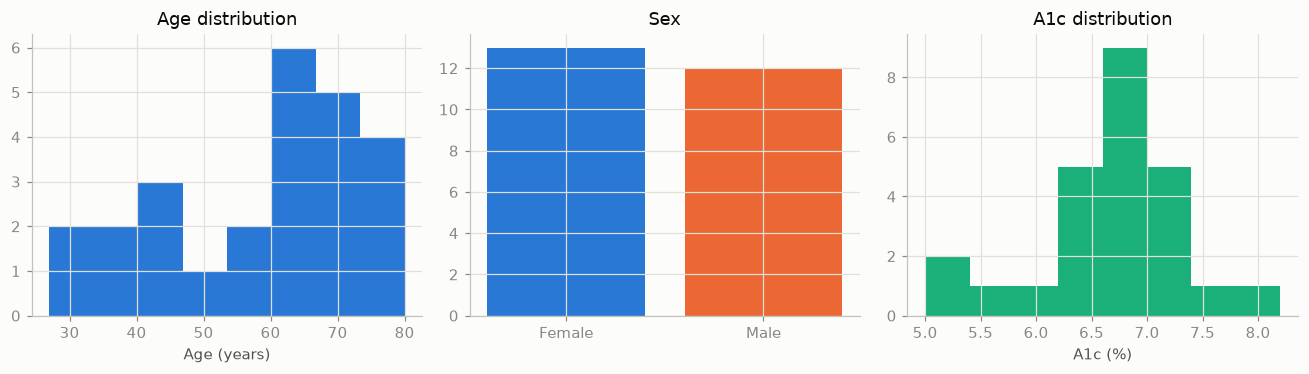

### What one patient's data actually looks like

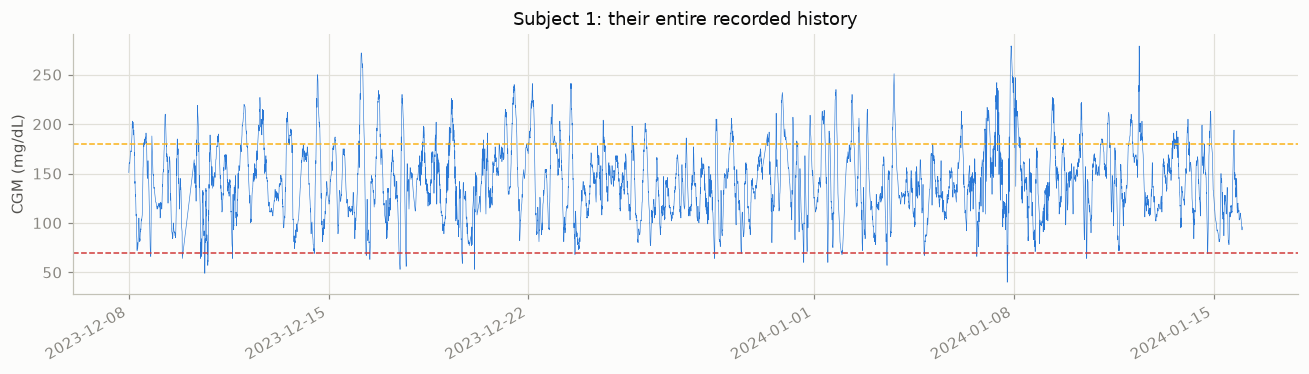

The dashed lines mark the danger thresholds. This one patient spent about 14% of their time above the high line and only about 1% below the low one -- a pattern that holds across the whole group too, covered next.

## 3. What's unusual about this data

A few patterns worth knowing before looking at any model results, since they shape what "doing well" even means here.

### Glucose readings lean high, not low

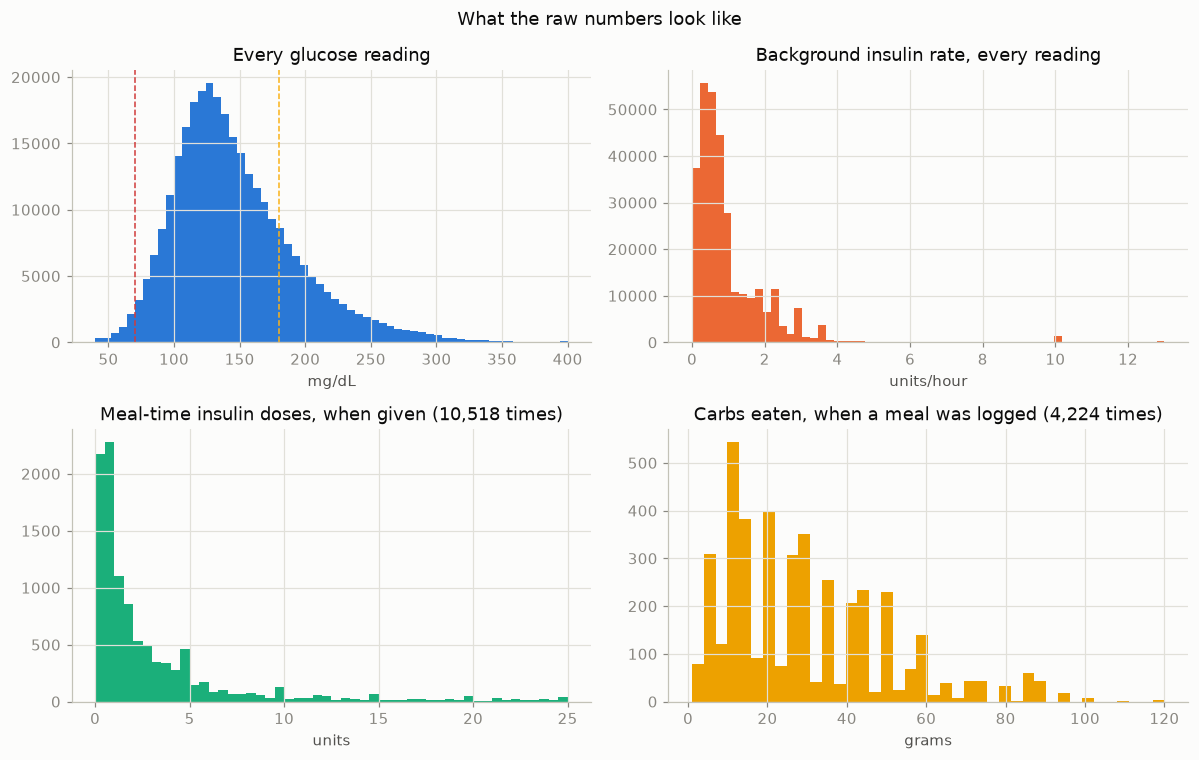

Across the whole group, readings are high (above 180) about 20% of the time but low (below 70) only about 2% of the time. That makes sense two ways: patients and their pumps actively try to avoid going low, since the immediate risk is worse there, and glucose has a hard floor at zero that the high end doesn't have. It also means the hypo cases a model needs to catch are rare to begin with.

### Some patients are much harder to predict for than others

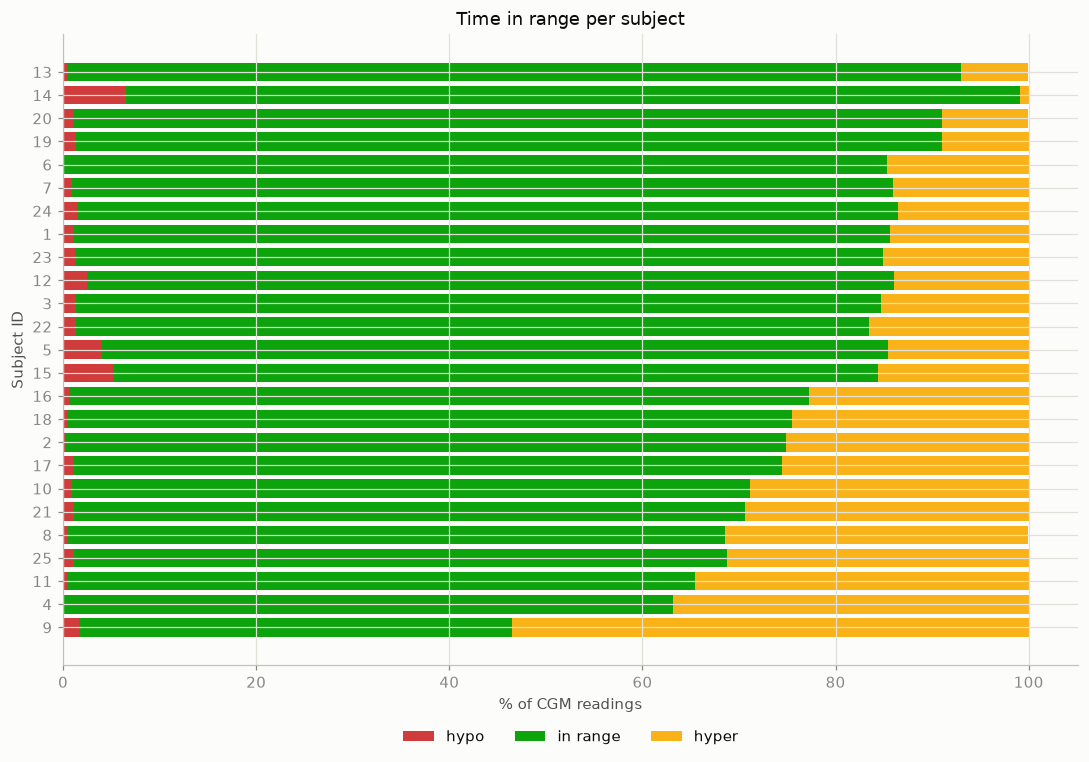

Time spent in the healthy range (70-180 mg/dL) ranges from under 50% for the toughest-controlled patient to over 90% for the best-controlled one. Later on, prediction accuracy tracks this almost exactly -- patients with more erratic glucose are harder to predict for, not because the model is worse at them specifically, but because their own data is intrinsically harder to forecast.

### A few patients are extreme outliers in how much they log

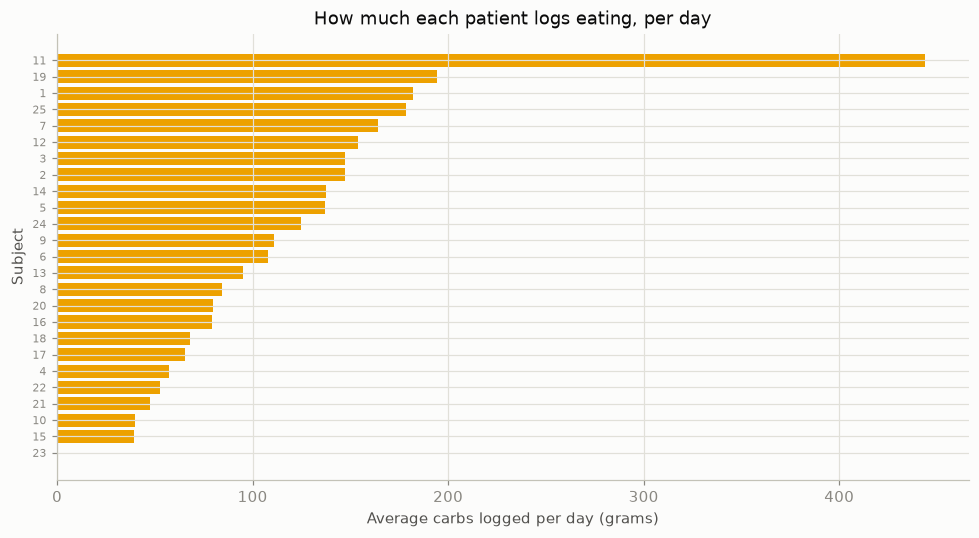

Most patients log a fairly typical amount of carbs per day, but a couple are far outside that range -- one logs almost none, one logs far more than anyone else. Worth remembering when a specific patient's model results look unusual later: sometimes it's the data, not the model.

### Risk isn't spread evenly across the day

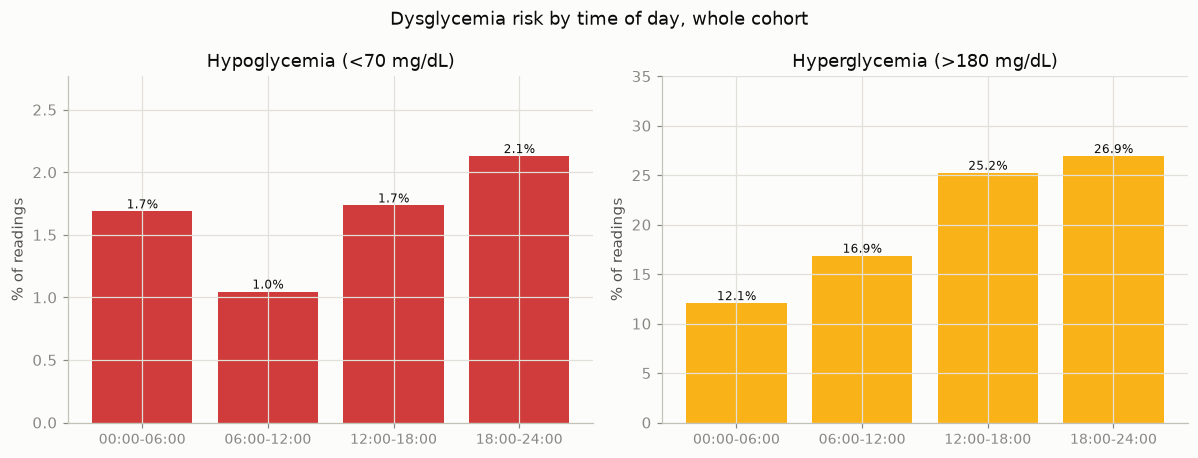

Hyperglycemia climbs steadily through the day, from 12.1% overnight (00:00-06:00) to 26.9% in the evening (18:00-24:00) -- consistent with meals accumulating their effect over the day. Hypoglycemia is a much smaller share throughout, but still highest in the evening (18:00-24:00, 2.1%). Both kinds of risk peak at the same time of day, not opposite ends of it.

## 4. The models

**How a model is tested:** each patient gets their own personal model (not one model shared across everyone), trained on their own history. It looks at the last 2 hours of glucose/insulin/carb data and predicts glucose 1 hour ahead. The most recent stretch of each patient's data is held back and never shown to the model during training, so every result below is measured on data the model has never seen.

**Three ways of training that model get compared throughout this part.** All three use the same architecture, same data, same features -- the only thing that changes is what the model gets penalized for getting wrong while it trains.

**Standard.** The model is scored by one plain average error across every prediction, treating a mistake at 90 mg/dL exactly the same as a mistake at 40 mg/dL or 250 mg/dL. Nothing tells it that some mistakes are more dangerous than others.

**Fixed danger-weighted.** Every prediction error is first sorted into one of three zones based on what the *true* glucose value actually was: hypo (below 70 mg/dL), normal (70-180), or hyper (above 180). The error is averaged within each zone separately, and then the three zone-averages are combined using different weights instead of one flat average: a mistake during a hypo moment counts 3.29x as much as a mistake during a normal moment, and a mistake during a hyper moment counts 2.38x as much. Those specific numbers are the paper's own published weights, applied here as one fixed setting for every patient. Mechanically, this changes what the model is optimizing for: since it's now scored mostly on how it does in the hypo/hyper zones, it has an incentive to spend its (limited) capacity getting those zones right, even if that means drifting slightly on the normal zone, which now counts for less. That's the direct cause of the trade-off in the chart below -- it's not a side effect, it's the model doing exactly what it was told to prioritize.

**Personalized danger-weighted.** Same mechanism as fixed danger-weighted, except the (3.29, 2.38)-style weight pair isn't shared across everyone -- each patient gets their own pair, found by a search that tries many candidate weight settings for that one patient and keeps whichever performs best on their own held-out validation data. The premise is that one fixed setting is a compromise: it's tuned to whatever the *average* patient needs, which may be too aggressive for someone whose glucose is already fairly stable, or not aggressive enough for someone who swings wildly. In practice, most patients' individually-found weights come out gentler than the fixed (3.29, 2.38) setting, with a couple of patients needing something much stronger -- which is exactly why personalized training lands *between* standard and fixed danger-weighted in the results below, rather than matching either one: most patients are being pushed less hard than the fixed setting pushes them, while the few who need a strong correction still get one.

All three appear together in every comparison below, so what changes is only which of these three trained the model, never the data or the architecture.

### A first look: one patient, three predictions

Before the aggregate numbers, here's what all three approaches actually predict on the same stretch of one patient's held-out data -- the same real glucose values, three different models trying to guess them 60 minutes ahead of time.

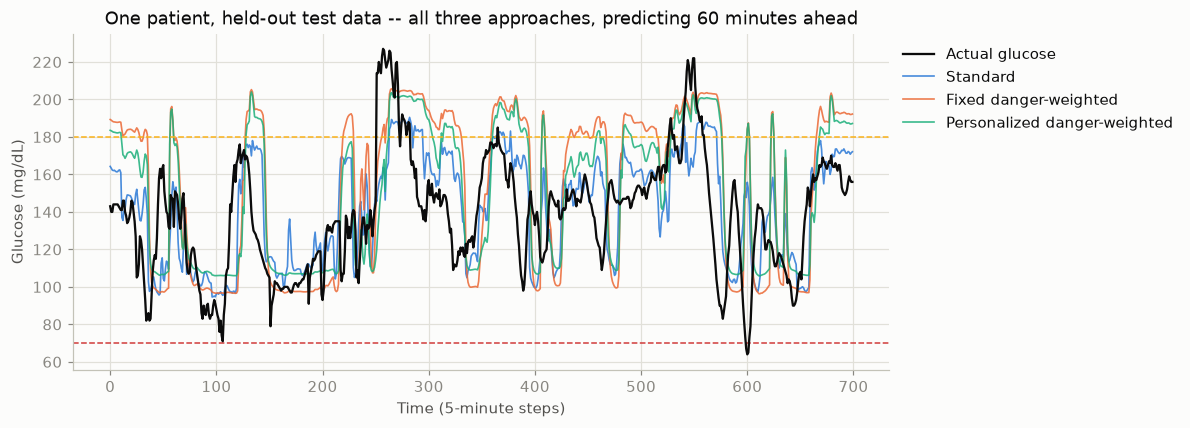

The standard model (blue) tracks the real value well in the middle of the range, but lags and undershoots right at the sharp highs and lows -- exactly the moments that matter most clinically. Fixed and personalized danger-weighted (orange and green) visibly sit above the standard prediction through most of this stretch, including during ordinary, non-dangerous moments -- a visible look at the same cost the region-by-region numbers below put a figure on. That same upward lean pays off at the sharp peak around step 550, where the danger-weighted lines track the true high more closely than standard does.

### Comparing all three approaches

As a reminder: **standard** is trained with no special attention to danger zones, **fixed danger-weighted** trains every patient with the same (3.29, 2.38) weighting toward hypo/hyper errors, and **personalized danger-weighted** trains each patient with their own individually-found version of that weighting (see the full explanation earlier in this part). Here's what actually happens when all three get compared directly, starting with where the errors land.

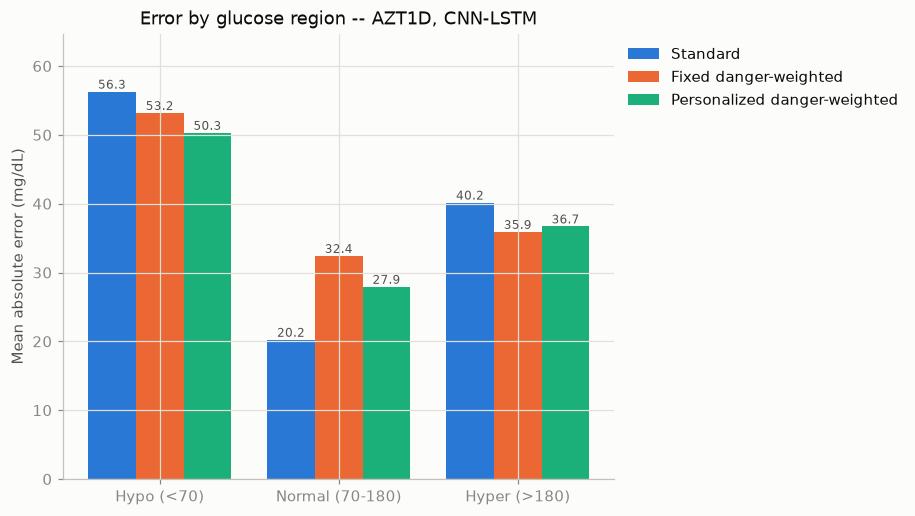

This is the actual mechanism: danger-weighting (fixed or personalized) brings hypo and hyper error down, exactly as intended, but normal-zone error goes up enough that overall accuracy (averaged across everything) ends up worse than standard's. Personalizing the weights per patient recovers some of that loss but not all of it. A real trade-off, not a straightforward win.

**Does that trade-off matter clinically?** Two more direct checks:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Precision</th>
      <th>Recall</th>
      <th>F1</th>
    </tr>
    <tr>
      <th>Training approach</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Standard</th>
      <td>0.68</td>
      <td>0.51</td>
      <td>0.58</td>
    </tr>
    <tr>
      <th>Fixed danger-weighted</th>
      <td>0.37</td>
      <td>0.72</td>
      <td>0.49</td>
    </tr>
    <tr>
      <th>Personalized danger-weighted</th>
      <td>0.46</td>
      <td>0.68</td>
      <td>0.55</td>
    </tr>
  </tbody>
</table>

Danger-weighting pushes recall (catching real dangerous moments) up substantially, at the cost of precision (more false alarms) -- fixed weighting more so, personalized a smaller version of the same trade.

The Clarke Error Grid is the standard clinical-accuracy tool for glucose predictions. Instead of just measuring how far off a prediction was in mg/dL, it grades every (actual, predicted) pair into one of five zones by what a person would actually do differently because of the error:

- **Zone A -- clinically accurate.** The prediction is close enough (within 20% of the true value, or both actual and predicted agree it's a hypo) that it wouldn't change what someone does.
- **Zone B -- benign error.** Off by more than zone A, but still not enough to lead to an inappropriate action -- an imprecise reading, not a harmful one.
- **Zone C -- overcorrection risk.** The prediction is wrong in a way that could prompt treating a glucose level that didn't actually need it (e.g. predicting a high when the true value was normal, prompting an unneeded correction dose).
- **Zone D -- dangerous miss.** A real dangerous moment (truly low or truly high) gets predicted as normal, so no action gets taken when one was actually needed. The worst kind of miss for a warning system, since it fails silently.
- **Zone E -- opposite-direction error.** The prediction and the true value are on opposite extremes (predicted low when actually high, or vice versa) -- the single worst case, since it could prompt exactly the wrong action.

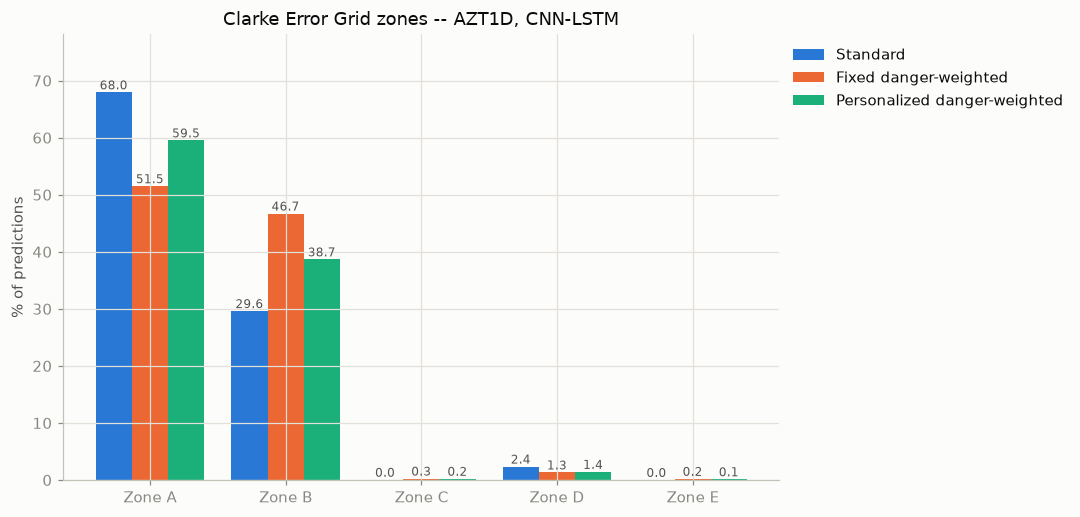

Zone D drops meaningfully with danger-weighted training, fixed or personalized -- fewer of the misses that would actually matter, even though zone A (plain accuracy) drops too.

## 5. Does this hold up across architectures and datasets

Everything above used one architecture (CNN-LSTM) on one dataset (AZT1D), to explain the idea with one running example. On its own, that's not enough to trust the result -- it could be specific to that one model design or that one group of patients. So here's the same check, repeated on a second architecture (CNN-Transformer) and a second, independent dataset (OhioT1DM).

**What to look for in both charts below:** the same order every time -- standard most accurate, fixed danger-weighted least accurate, personalized in between, closer to standard. If that order holds on a different model design and a different real-world dataset, that's strong evidence it's a real pattern, not a coincidence of one setup.

**AZT1D** -- both architectures, all three approaches:

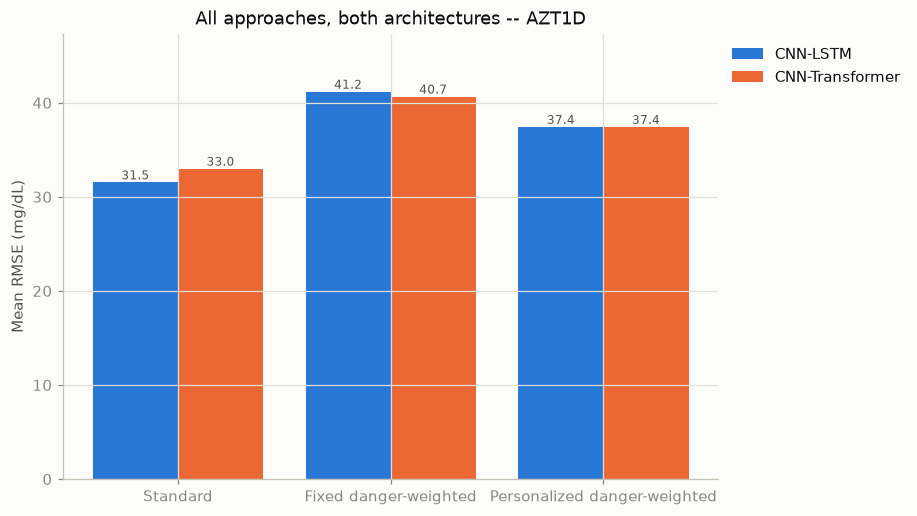

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Standard RMSE</th>
      <th>Fixed danger-weighted RMSE</th>
      <th>Personalized danger-weighted RMSE</th>
    </tr>
    <tr>
      <th>Architecture</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>CNN-LSTM</th>
      <td>31.54 +/- 6.10</td>
      <td>41.18 +/- 5.88</td>
      <td>37.44 +/- 6.35</td>
    </tr>
    <tr>
      <th>CNN-Transformer</th>
      <td>32.99 +/- 6.87</td>
      <td>40.66 +/- 4.92</td>
      <td>37.43 +/- 5.49</td>
    </tr>
  </tbody>
</table>

**OhioT1DM** -- the same comparison, on a second, independent dataset:

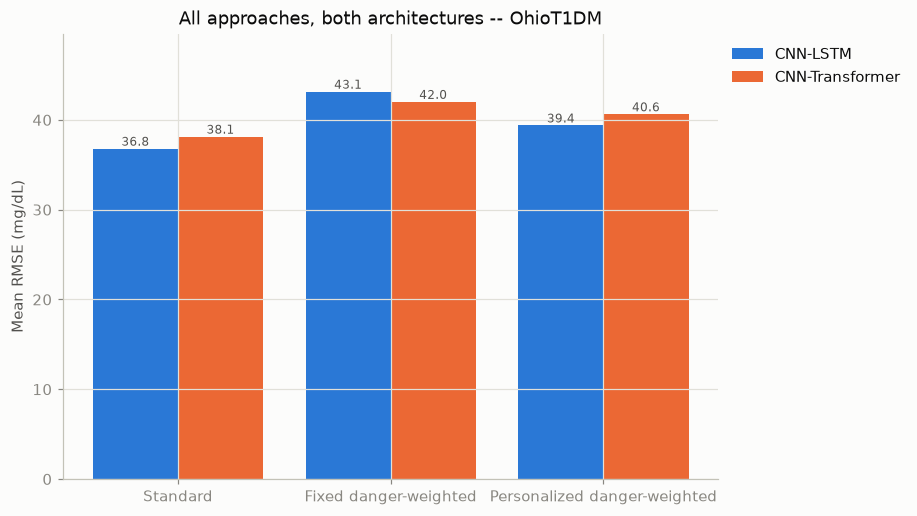

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Standard RMSE</th>
      <th>Fixed danger-weighted RMSE</th>
      <th>Personalized danger-weighted RMSE</th>
    </tr>
    <tr>
      <th>Architecture</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>CNN-LSTM</th>
      <td>36.79 +/- 4.37</td>
      <td>43.14 +/- 6.51</td>
      <td>39.38 +/- 6.46</td>
    </tr>
    <tr>
      <th>CNN-Transformer</th>
      <td>38.13 +/- 4.40</td>
      <td>42.01 +/- 6.17</td>
      <td>40.63 +/- 5.36</td>
    </tr>
  </tbody>
</table>

The order holds in all four cases (2 architectures x 2 datasets): standard is always most accurate, fixed danger-weighted always least accurate, personalized always in between. That's good evidence this is a real, general pattern rather than something specific to one model or one dataset.

Two things worth flagging: the (3.29, 2.38) fixed weights used throughout actually came from a genetic algorithm search on OhioT1DM specifically (the paper's own choice, not this project's). Running the same personalized search on OhioT1DM directly -- the most direct check available -- found consistently gentler weights than that reference value, not stronger ones. And on OhioT1DM specifically, the fixed weighting actually beat personalized tuning in the hypo zone, the one place the two datasets disagreed.

## 6. How does this compare to the original GLIMMER paper

Everything so far compares this project's own approaches against each other. The table below is the more important comparison: how do this project's numbers stack up against what the paper itself reported? (CNN-LSTM only -- the paper doesn't report a directly comparable Transformer number.)

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Paper's baseline</th>
      <th>Paper's GLIMMER (best)</th>
      <th>This project, standard</th>
      <th>This project, personalized (best)</th>
    </tr>
    <tr>
      <th>Dataset</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>AZT1D</th>
      <td>29.55 +/- 6.49</td>
      <td>22.48 +/- 3.57</td>
      <td>31.54 +/- 6.10</td>
      <td>37.44 +/- 6.35</td>
    </tr>
    <tr>
      <th>OhioT1DM</th>
      <td>31.98 +/- 4.15</td>
      <td>23.97 +/- 3.77</td>
      <td>36.79 +/- 4.37</td>
      <td>39.38 +/- 6.46</td>
    </tr>
  </tbody>
</table>

Two things to take from this table. First, **this project's standard model is a reasonable replication of the paper's own baseline** -- close on both datasets, not off by some large, suspicious margin, which is a basic sanity check that this implementation is doing roughly the right thing before trusting anything built on top of it. Second, and more important: **the paper's GLIMMER (their best danger-weighted result) beats their own baseline** on both datasets, while **this project's personalized danger-weighted result does not beat its own standard model** on either dataset -- the opposite direction. That gap, not any of the internal comparisons above, is the real headline finding of this replication.

### Why the gap? A few theories

None of these are proven. They're written in plain terms below and ranked from most to least confident -- based on how much real evidence supports each one, not just on how reasonable it sounds.

**1. The search for each patient's own settings is much smaller here than in the paper.** This is the theory with actual evidence behind it, not just a guess. Finding a patient's own personalized settings works like trying a handful of different options, keeping whichever works best for that person, then repeating that a few times to refine it further. This project only tries 6 options at a time, repeated 6 times (21 tries total per patient). The original paper tries 20 options at a time, repeated 25 times -- over 10 times more searching. Here's the evidence: this project's own search was run directly on the exact dataset (OhioT1DM) that the paper's own published settings came from, and it never landed anywhere close to those numbers -- every patient came back with a much gentler setting. A smaller search consistently settling for weaker adjustments is a real, checkable pattern, not just a hunch.

**2. The paper doesn't say exactly how the model was built, and the guesses made here might not match theirs.** Things like how far back in time the model looks, how big it is on the inside, and how long it spends training aren't fully spelled out in the paper -- this project had to make reasonable guesses for all of that. A model built even slightly differently might handle this same trade-off differently. A smaller model in particular has less room to be good at two things at once (everyday accuracy and danger-zone accuracy), which could make the trade-off look worse here than it needs to.

**3. Which version of the model gets kept, while it's training, might be decided differently.** A model improves gradually while it trains, and at some point training stops and one version gets kept as "the model." This project always keeps whichever version was doing best on everyday accuracy, even for the versions meant to prioritize danger zones -- done on purpose, since the danger-zone score is unreliable when checked against such a small slice of each patient's data. If the paper instead kept whichever version scored best on the danger-zone measure itself, that would naturally make their danger-weighted results look stronger than this project's.

**4. A few smaller, harder-to-check possibilities.** These are the least certain. The paper describes some things in plain words rather than an exact rule (what exactly counts as a "dangerous moment," for instance), so this project's own interpretation might not exactly match theirs. There could also be small differences in the data itself, or the paper's published numbers might reflect their single best attempt out of several tries rather than one plain run -- there's no way to tell either way just from reading the paper.

## 7. Bottom line

Danger-weighted training is a real trade, not a free win: it makes the model less accurate on average but more likely to catch the moments that actually matter clinically -- more real hypo/hyper events detected, and meaningfully fewer dangerous misses on the Clarke Error Grid. Personalizing those weights per patient, instead of using one fixed setting, recovers some but not all of the accuracy that fixed weighting gives up, consistently across both model designs and both real-world datasets tested. What it doesn't do, on either dataset, is beat the paper's own reported improvement over its baseline -- the theories for that gap are laid out in the section above, with a bigger personalized-weight search (see `azt1d/glimmer/ga.py`) the most concrete next step if this needs to go further.